# Stochastic Gradient Descent

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import time
import re
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

e:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens\notebooks
E:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens


## Data Acquisition

load dataset

In [3]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz').tocsr()
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 100000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz').tocsr()
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 100000)
y_valid shape: (20000,)


In [5]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz').tocsr()
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 100000)
y_test shape: (20000,)


## Hyperparameter Tuning with GridSearchCV

SGD is a fast, scalable linear model ideal for large sparse datasets like TF-IDF.
We use `GridSearchCV` to systematically find optimal hyperparameters balancing convergence speed, regularization, and performance.

> **Key Hyperparameters for SGD Classifier:**
> - `loss`: Loss function ('hinge' for SVM-like, 'log' for logistic regression)
> - `penalty`: Regularization type ('l1', 'l2', 'elasticnet')
> - `alpha`: Regularization strength (lower = less regularization)
> - `learning_rate`: Schedule for learning rate ('constant', 'optimal', 'invscaling', 'adaptive')
> - `eta0`: Initial learning rate (controls step size)
> - `max_iter`: Maximum iterations (ensures convergence)

In [ ]:
# Define the hyperparameter search space for SGD
param_grid = {
    'loss': ['hinge', 'log', 'squared_hinge'],              # Loss function
    'penalty': ['l1', 'l2', 'elasticnet'],                  # Regularization type
    'alpha': [0.00001, 0.0001, 0.001, 0.01],               # Regularization strength
    'learning_rate': ['constant', 'optimal', 'invscaling'],# Learning rate schedule
    'eta0': [0.001, 0.01, 0.1],                            # Initial learning rate
    'max_iter': [500, 1000, 1500],                         # Convergence iterations
}
# Base estimator — SGDClassifier
base_sgd = SGDClassifier(random_state=42, n_jobs=-1, early_stopping=True, validation_fraction=0.1)
print("Starting GridSearchCV for SGD Classifier...")
search_start = time.time()
grid_search = GridSearchCV(
    estimator=base_sgd,
    param_grid=param_grid,
    scoring='f1',              # Optimize for F1 (balanced metric for binary sentiment)
    cv=3,                      # 3-fold cross-validation on training data
    n_jobs=-1,                 # Use all available cores
    verbose=2,
    refit=True                 # Refit best model on the full training set
)
grid_search.fit(X_train_tfidf, y_train)
search_time = time.time() - search_start
print(f"\nGridSearchCV completed in {search_time:.4f} seconds")

Starting GridSearchCV for SGD Classifier...
Fitting 3 folds for each of 972 candidates, totalling 2916 fits

GridSearchCV completed in 96.5909 seconds


In [7]:
# Inspect the best hyperparameters found
print("Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1-Score: {grid_search.best_score_:.4f}")

Best Parameters:
  alpha: 1e-05
  eta0: 0.1
  learning_rate: constant
  loss: hinge
  max_iter: 500
  penalty: elasticnet

Best CV F1-Score: 0.8880


In [8]:
# CV results summary — top 10 combinations
cv_results = pd.DataFrame(grid_search.cv_results_)
top_results = (
    cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
)
print("Top 10 hyperparameter combinations (by F1):")
print(top_results.to_string(index=False))

Top 10 hyperparameter combinations (by F1):
                                                                                                                         params  mean_test_score  std_test_score  rank_test_score
          {'alpha': 1e-05, 'eta0': 0.1, 'learning_rate': 'constant', 'loss': 'hinge', 'max_iter': 500, 'penalty': 'elasticnet'}         0.888008        0.001149                1
         {'alpha': 1e-05, 'eta0': 0.1, 'learning_rate': 'constant', 'loss': 'hinge', 'max_iter': 1500, 'penalty': 'elasticnet'}         0.888008        0.001149                1
         {'alpha': 1e-05, 'eta0': 0.1, 'learning_rate': 'constant', 'loss': 'hinge', 'max_iter': 1000, 'penalty': 'elasticnet'}         0.888008        0.001149                1
        {'alpha': 1e-05, 'eta0': 0.01, 'learning_rate': 'constant', 'loss': 'squared_hinge', 'max_iter': 1500, 'penalty': 'l2'}         0.887652        0.001534                4
        {'alpha': 1e-05, 'eta0': 0.01, 'learning_rate': 'constant'

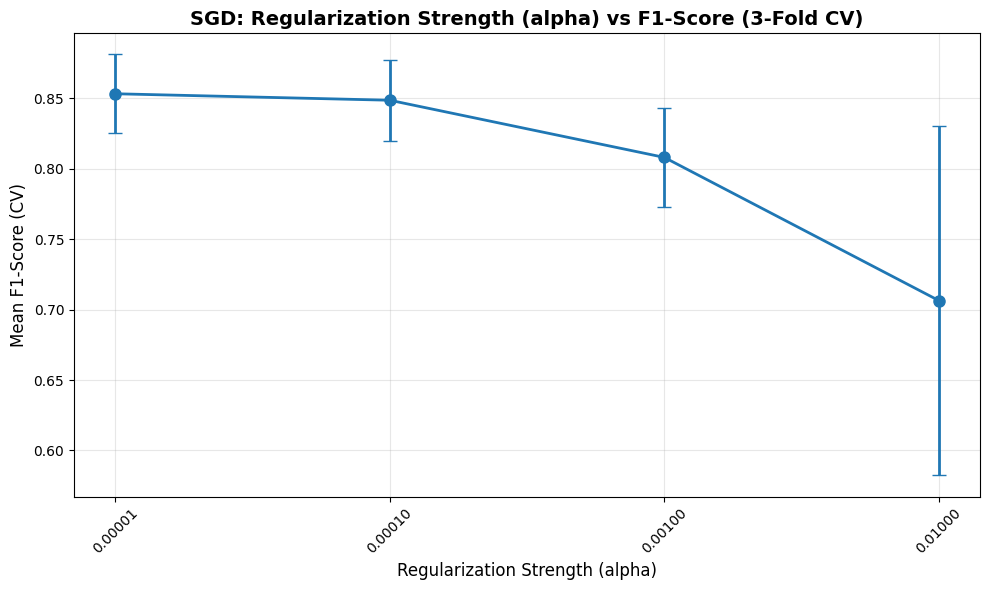


Regularization Strength (alpha) Performance Analysis:
  alpha     mean      std
0.00001 0.853344 0.027958
0.00010 0.848741 0.028767
0.00100 0.808144 0.034962
0.01000 0.706480 0.124221


In [ ]:
# Analyze the effect of alpha (regularization strength) on F1-score
cv_df = pd.DataFrame(grid_search.cv_results_)
cv_df['alpha'] = cv_df['params'].apply(lambda x: x['alpha'])

# Average performance by alpha
alpha_performance = cv_df.groupby('alpha')['mean_test_score'].agg(['mean', 'std']).reset_index()
alpha_performance = alpha_performance.sort_values('alpha')

# Plot alpha sensitivity
plt.figure(figsize=(10, 6))
plt.errorbar(np.arange(len(alpha_performance)), alpha_performance['mean'], 
             yerr=alpha_performance['std'], marker='o', capsize=5, linewidth=2, markersize=8)
plt.xlabel('Regularization Strength (alpha)', fontsize=12)
plt.ylabel('Mean F1-Score (CV)', fontsize=12)
plt.title('SGD: Regularization Strength (alpha) vs F1-Score (3-Fold CV)', fontsize=14, fontweight='bold')
plt.xticks(np.arange(len(alpha_performance)), [f'{a:.5f}' for a in alpha_performance['alpha']], rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('docs/02_results/sgd_alpha_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRegularization Strength (alpha) Performance Analysis:")
print(alpha_performance.to_string(index=False))

## SGD Model Training with Optimized Hyperparameters

We use the best parameters discovered via GridSearchCV and train the final model on the **full** training set (already done by `refit=True` in `GridSearchCV`).

In [10]:
# Retrieve the best estimator (already refit on the full training set)
sgd_classifier = grid_search.best_estimator_

print(f"Final SGD Model trained with best hyperparameters:")
print(f"  Training set size: {X_train_tfidf.shape}")
print(f"  Loss Function: {sgd_classifier.loss}")
print(f"  Regularization (alpha): {sgd_classifier.alpha}")
print(f"  Penalty Type: {sgd_classifier.penalty}")
print(f"  Iterations to Convergence: {sgd_classifier.n_iter_}")
print(f"  F1-Score (CV): {grid_search.best_score_:.4f}")

Final SGD Model trained with best hyperparameters:
  Training set size: (79972, 100000)
  Loss Function: hinge
  Regularization (alpha): 1e-05
  Penalty Type: elasticnet
  Iterations to Convergence: 13
  F1-Score (CV): 0.8880


## Model Evaluation

In [ ]:
# Make predictions
y_pred = sgd_classifier.predict(X_test_tfidf)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("SGD CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {search_time:.4f} seconds")

SGD CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.8903
Precision: 0.8884
Recall:    0.8920
F1-Score:  0.8902


## Classification Report

In [12]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89      9966
    Positive       0.89      0.89      0.89     10034

    accuracy                           0.89     20000
   macro avg       0.89      0.89      0.89     20000
weighted avg       0.89      0.89      0.89     20000



## Confusion Matrix Visualization

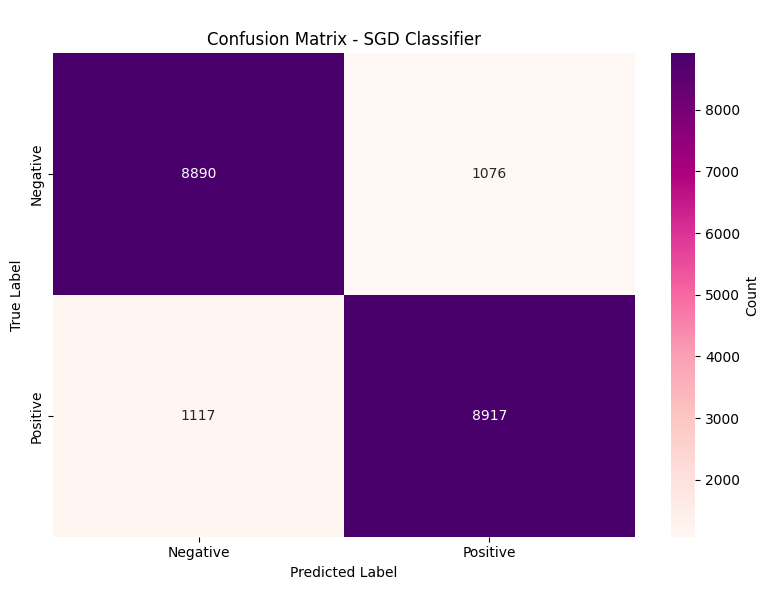

Confusion Matrix:
[[8890 1076]
 [1117 8917]]

True Negatives: 8890
False Positives: 1076
False Negatives: 1117
True Positives: 8917


In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('\nConfusion Matrix - SGD Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('docs/02_results/sgd_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Feature Coefficients (Feature Importance for Linear Models)

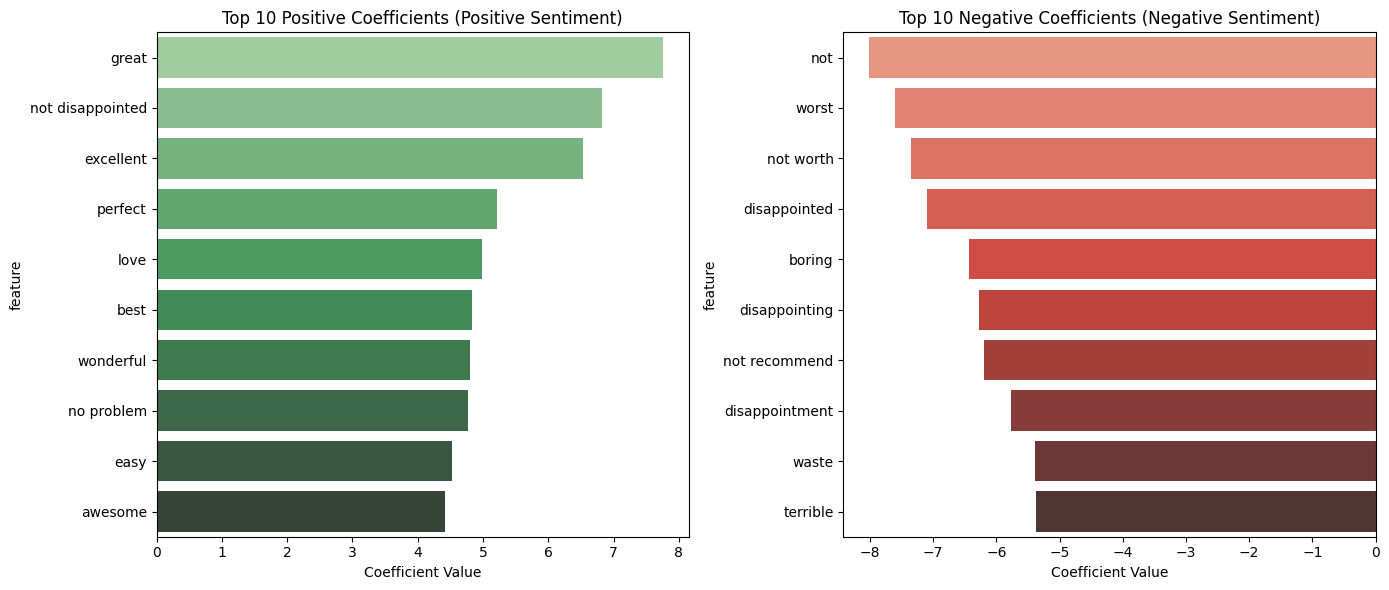


Top 10 Positive Coefficients:
         feature  coefficient
           great     7.765168
not disappointed     6.818849
       excellent     6.527532
         perfect     5.208471
            love     4.991220
            best     4.824155
       wonderful     4.793619
      no problem     4.768792
            easy     4.525161
         awesome     4.414572

Top 10 Negative Coefficients:
       feature  coefficient
           not    -8.018637
         worst    -7.598298
     not worth    -7.350697
  disappointed    -7.095165
        boring    -6.434153
 disappointing    -6.273222
 not recommend    -6.198155
disappointment    -5.762950
         waste    -5.387459
      terrible    -5.379825


In [ ]:
# Get feature coefficients
tfidf_vectorizer = joblib.load('data/vectorizers/tfidf_vectorizer.joblib')
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = sgd_classifier.coef_[0]
# Create DataFrame for better visualization
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})
# Get top positive and negative features
top_positive = coef_df.nlargest(10, 'coefficient')
top_negative = coef_df.nsmallest(10, 'coefficient')
# Plot top coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=top_positive, x='coefficient', y='feature', palette='Greens_d', ax=axes[0])
axes[0].set_title('Top 10 Positive Coefficients (Positive Sentiment)')
axes[0].set_xlabel('Coefficient Value')
sns.barplot(data=top_negative, x='coefficient', y='feature', palette='Reds_d', ax=axes[1])
axes[1].set_title('Top 10 Negative Coefficients (Negative Sentiment)')
axes[1].set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('docs/02_results/sgd_feature_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 10 Positive Coefficients:")
print(top_positive.to_string(index=False))
print("\nTop 10 Negative Coefficients:")
print(top_negative.to_string(index=False))

## Model Convergence Analysis

In [15]:
# Check number of iterations
print(f"\nModel Convergence Information:")
print(f"Number of iterations: {sgd_classifier.n_iter_}")
print(f"Number of features: {sgd_classifier.n_features_in_}")
print(f"Classes: {sgd_classifier.classes_}")
print(f"Loss value: {sgd_classifier.loss}")


Model Convergence Information:
Number of iterations: 13
Number of features: 100000
Classes: [1 2]
Loss value: hinge


## Model Summary

In [ ]:
print("STOCHASTIC GRADIENT DESCENT MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Loss Function: {sgd_classifier.loss}")
print(f"  - Penalty: {sgd_classifier.penalty}")
print(f"  - Alpha (Learning Rate): {sgd_classifier.alpha}")
print(f"  - Max Iterations: {sgd_classifier.max_iter}")
print(f"  - Early Stopping: {sgd_classifier.early_stopping}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {search_time:.4f} seconds")
print(f"\nTraining Details:")
print(f"  - Iterations Required: {sgd_classifier.n_iter_}")
print(f"  - Number of Features Used: {sgd_classifier.n_features_in_}")

STOCHASTIC GRADIENT DESCENT MODEL SUMMARY

Model Parameters:
  - Loss Function: hinge
  - Penalty: elasticnet
  - Alpha (Learning Rate): 1e-05
  - Max Iterations: 500
  - Early Stopping: True

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.8903
  - Precision: 0.8884
  - Recall:    0.8920
  - F1-Score:  0.8902

Training Details:
  - Iterations Required: 13
  - Number of Features Used: 100000


## Saving the Model and Pipeline

In [17]:
save(model_base='data/models', model=sgd_classifier, model_name='11_stochastic_gradient_descent_classifier.joblib')

Saved model 11_stochastic_gradient_descent_classifier.joblib to data\models\11_stochastic_gradient_descent_classifier.joblib


{'model': WindowsPath('data/models/11_stochastic_gradient_descent_classifier.joblib')}